# Normalising the prediction errors

1. Read the pixel removal result file
2. Normalise the absolute error in prediction by the area; or use absolute error in prediction
3. Find the pixel number for which, for a given subject the error is maximum.
4. Look at the results

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats

import sys
sys.path.append("../scripts")

from error_norm import plot_max_error_pixel, read_metadata, MID, YOUNG

%load_ext autoreload
%autoreload 2

output_dir = "../output/removal_data_repl_interpol_6k"
plots_dir = "../output/data_removal_plots"

Path(plots_dir).mkdir(parents=True, exist_ok=True)

* 4096 pixels = 10 seconds
* 409.6 pixels = 1 second

* 1 hz = 1 per second
* 7 hz = 1 / 7 per second = 409.6 / 7 pixels


In [2]:
409.6 / 15

27.30666666666667

In [3]:
avg_arr = np.load("../data/one_beat_array.npy")
chan0_avg = avg_arr[:, :, 0].mean(axis=0)
del avg_arr

In [4]:
df_meta = read_metadata()

young_age = (df_meta['age'] <= YOUNG)
mid_age = (df_meta['age'] > YOUNG) & (df_meta['age'] <= MID)
old_age = (df_meta['age'] > MID)


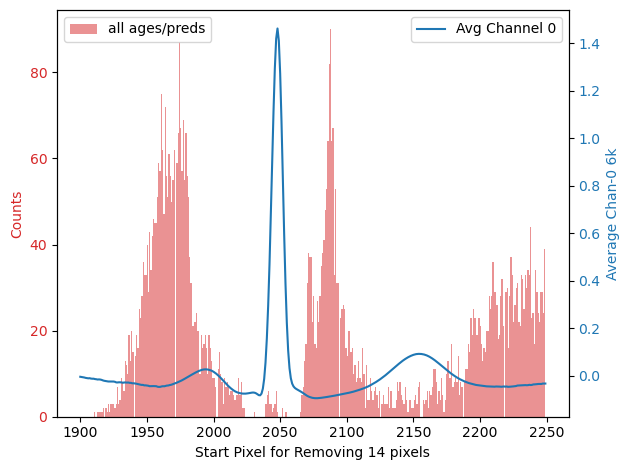

In [5]:
plot_max_error_pixel(
    pixels_removed=14,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=False,
)

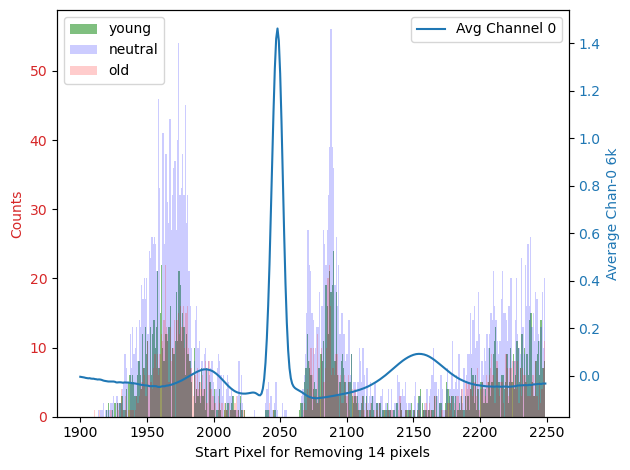

P-value for young vs neutral: 0.1342
P-value for young vs old: 0.328
P-value for neutral vs old: 0.8019


In [6]:
plot_max_error_pixel(
    pixels_removed=14,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=True,
)

In [7]:
df_meta.head()

,index,exam_id,data_arr_idx,start_beat,end_beat,channel_used,age,nn_predicted_age,pred_label,age_label
0,0,1750214,0,1893,2358,0,82,67.269160,young,old
1,1,1688724,1,1928,2288,1,44,40.132603,neutral,mid
2,2,1771393,2,1939,2266,0,51,55.314810,neutral,mid
3,3,1793030,3,1934,2275,0,28,43.013763,old,young
4,4,1717689,4,1973,2197,1,52,80.612400,old,mid


<Axes: >

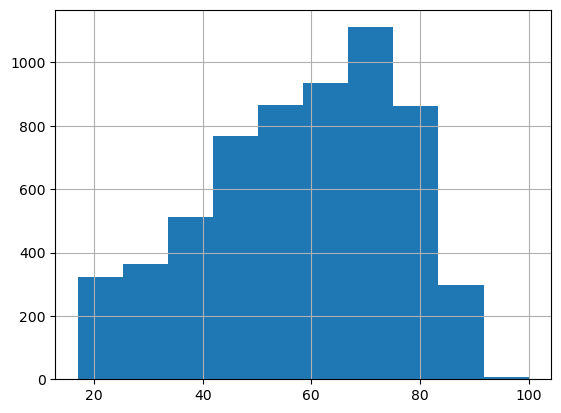

In [8]:
df_meta['age'].hist()

In [9]:
# young-young
((df_meta['age_label'] == 'young') & (df_meta['pred_label'] == 'young')).sum()

np.int64(73)

In [10]:
df_meta[young_age]['pred_label'].value_counts()

pred_label
neutral    685
old        381
young       73
Name: count, dtype: int64

In [11]:
df_meta[old_age]['pred_label'].value_counts()

pred_label
neutral    1689
young      1027
old         276
Name: count, dtype: int64

In [12]:
pixels_removed = 14
filename = f"{output_dir}/all_subjects_and_pixels_{pixels_removed}pixels_6k_sub.csv"
p = Path(filename)
if p.exists():
    df = pd.read_csv(filename)
else:
    raise FileNotFoundError(f"{filename} not found. Run the data removal script first.")
df.loc[:, 'norm_error'] = np.where(
    df['raw_prediction'] == df['replace_prediction'],
    0,
    abs(df['raw_prediction'] - df['replace_prediction']) / (df['replace_area'])
)

df.loc[:, 'abs_error'] = abs(df['raw_prediction'] - df['replace_prediction']) 



## Normalized Error

Comparison between 2 groups - young age with young prediction and old age with old prediction

In [13]:
# Per subject what pixel gives maximum norm_error
max_err_pixel = df.loc[
    df.groupby('subject')['norm_error'].idxmax(),
    ['subject', 'start_pixel']
].reset_index(drop=True)
max_err_pixel.loc[:, 'age_label'] = df_meta['age_label']
max_err_pixel.loc[:, 'pred_label'] = df_meta['pred_label']

young_young_pixel = max_err_pixel[
    (max_err_pixel['age_label'] == 'young') &
    (max_err_pixel['pred_label'] == 'young')
]['start_pixel'].values

old_old_pixel = max_err_pixel[
    (max_err_pixel['age_label'] == 'old') &
    (max_err_pixel['pred_label'] == 'old')
]['start_pixel'].values

statistic, p_value = stats.ttest_ind(young_young_pixel, old_old_pixel)
float(p_value)

4.126853402336597e-16

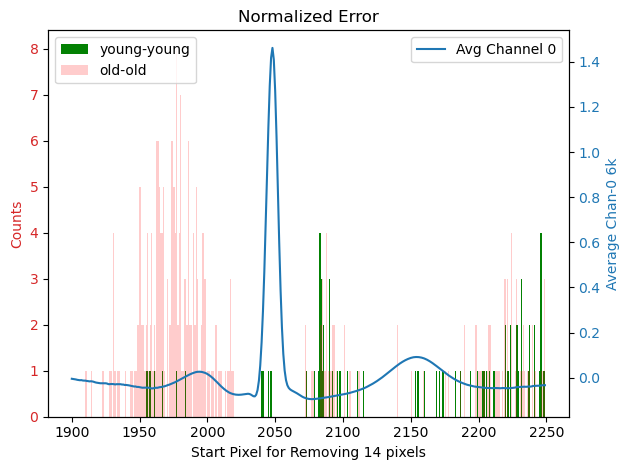

In [14]:
MIN_PIX = 1900
MAX_PIX = 2250

fig, ax1 = plt.subplots()
n_bins = MAX_PIX - MIN_PIX

color = 'tab:red'
ax1.set_xlabel(f'Start Pixel for Removing {pixels_removed} pixels')
ax1.set_ylabel('Counts', color=color)
ax1.hist(
    max_err_pixel[
        (max_err_pixel['pred_label'] == 'young') & young_age
    ]['start_pixel'],
    bins=n_bins, color='green', alpha=0.99, label='young-young',
)
ax1.hist(
    max_err_pixel[
        (max_err_pixel['pred_label'] == 'old') & old_age
     ]['start_pixel'],
    bins=n_bins, color='red', alpha=0.2, label='old-old',
)

ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Average Chan-0 6k', color=color)  # we already handled the x-label with ax1
pixels = [pix for pix in range(MIN_PIX, MAX_PIX)]
ax2.plot(pixels, chan0_avg[MIN_PIX: MAX_PIX], color=color, label='Avg Channel 0')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title("Normalized Error")
fig.tight_layout()

## Absolute Error

Comparison between 2 groups - young age with young prediction and old age with old prediction

In [15]:
# Per subject what pixel gives maximum norm_error
max_err_pixel = df.loc[
    df.groupby('subject')['abs_error'].idxmax(),
    ['subject', 'start_pixel']
].reset_index(drop=True)
max_err_pixel.loc[:, 'age_label'] = df_meta['age_label']
max_err_pixel.loc[:, 'pred_label'] = df_meta['pred_label']

young_young_pixel = max_err_pixel[
    (max_err_pixel['age_label'] == 'young') &
    (max_err_pixel['pred_label'] == 'young')
]['start_pixel'].values

old_old_pixel = max_err_pixel[
    (max_err_pixel['age_label'] == 'old') &
    (max_err_pixel['pred_label'] == 'old')
]['start_pixel'].values

statistic, p_value = stats.ttest_ind(young_young_pixel, old_old_pixel)
float(p_value)

0.017976750316553974

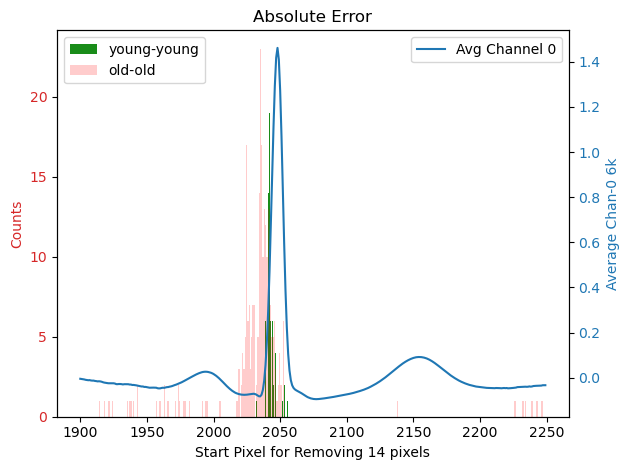

In [16]:
MIN_PIX = 1900
MAX_PIX = 2250

fig, ax1 = plt.subplots()
n_bins = MAX_PIX - MIN_PIX

color = 'tab:red'
ax1.set_xlabel(f'Start Pixel for Removing {pixels_removed} pixels')
ax1.set_ylabel('Counts', color=color)
ax1.hist(
    max_err_pixel[
        (max_err_pixel['pred_label'] == 'young') & young_age
    ]['start_pixel'],
    bins=n_bins, color='green', alpha=0.9, label='young-young',
)
ax1.hist(
    max_err_pixel[
        (max_err_pixel['pred_label'] == 'old') & old_age
     ]['start_pixel'],
    bins=n_bins, color='red', alpha=0.2, label='old-old',
)

ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Average Chan-0 6k', color=color)  # we already handled the x-label with ax1
pixels = [pix for pix in range(MIN_PIX, MAX_PIX)]
ax2.plot(pixels, chan0_avg[MIN_PIX: MAX_PIX], color=color, label='Avg Channel 0')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title("Absolute Error")
fig.tight_layout()

## Absolute error

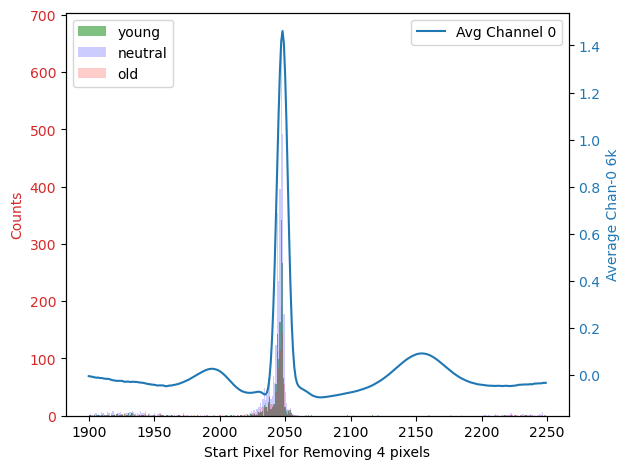

P-value for young vs neutral: 0.2435
P-value for young vs old: 0.2183
P-value for neutral vs old: 0.6433


In [17]:
plot_max_error_pixel(
    pixels_removed=4,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=True,
    use_norm_error=False,
)

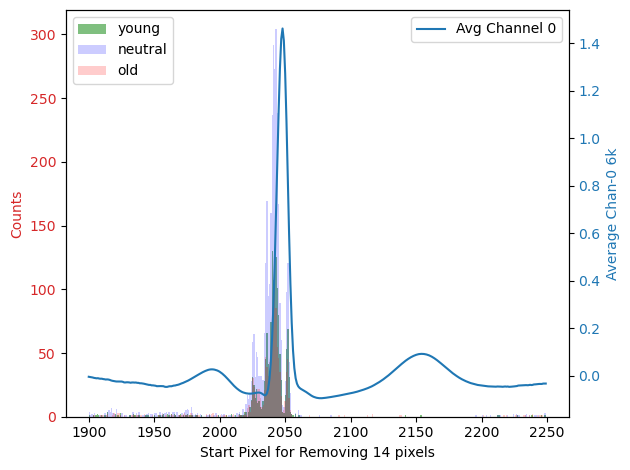

P-value for young vs neutral: 0.0299
P-value for young vs old: 0.3936
P-value for neutral vs old: 0.5032


In [18]:
plot_max_error_pixel(
    pixels_removed=14,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=True,
    use_norm_error=False,
)

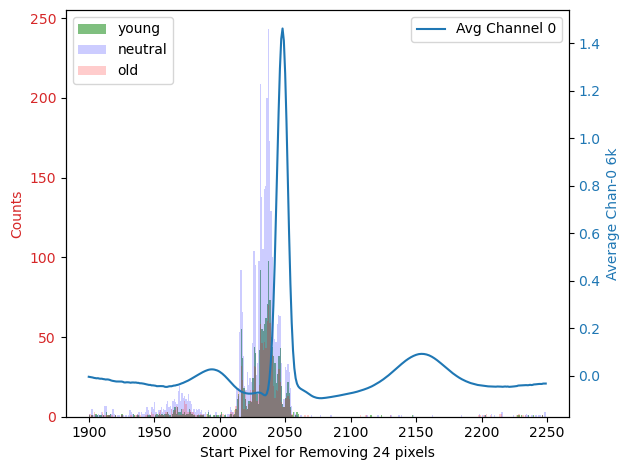

P-value for young vs neutral: 0.0008
P-value for young vs old: 0.0525
P-value for neutral vs old: 0.6426


In [19]:
plot_max_error_pixel(
    pixels_removed=24,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=True,
    use_norm_error=False,
)

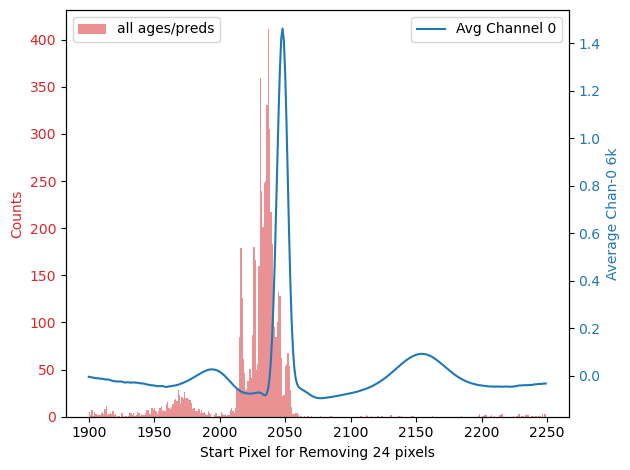

In [20]:
plot_max_error_pixel(
    pixels_removed=24,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=False,
    use_norm_error=False,
)

## Normalised error

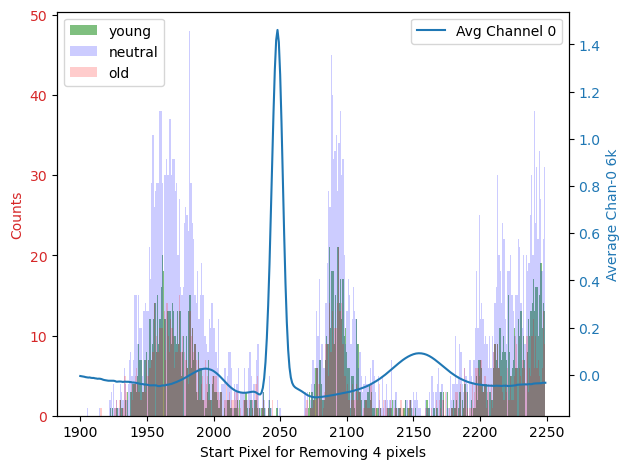

P-value for young vs neutral: 0.0112
P-value for young vs old: 0.0049
P-value for neutral vs old: 0.364


In [21]:
plot_max_error_pixel(
    pixels_removed=4,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=True,
    use_norm_error=True,
)

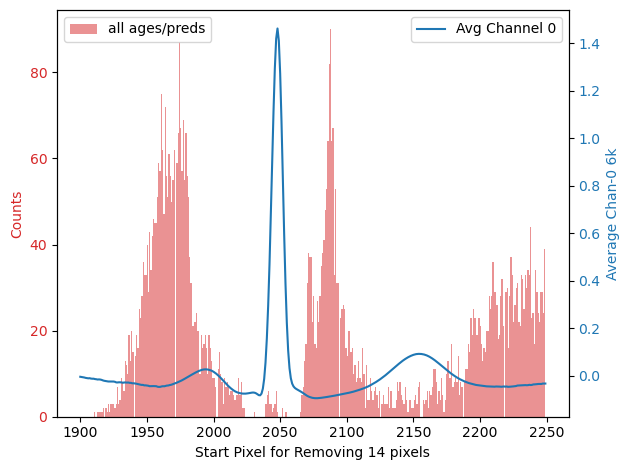

In [35]:
plot_max_error_pixel(
    pixels_removed=14,
    df_meta=df_meta,
    chan0_avg=chan0_avg,
    save_plot=False,
    is_age_group=False,
    use_norm_error=True,
)

## Average error per pixel

In [25]:
output_dir = "../output/removal_data_repl_interpol_6k"
pixels_removed = 14
filename = f"{output_dir}/all_subjects_and_pixels_{pixels_removed}pixels_6k_sub.csv"
p = Path(filename)
if p.exists():
    df = pd.read_csv(filename)

else:
    raise FileNotFoundError(f"{filename} not found. Run the data removal script first.")

df.loc[:, 'norm_error'] = np.where(
    df['raw_prediction'] == df['replace_prediction'],
    0,
    abs(df['raw_prediction'] - df['replace_prediction']) / (df['replace_area'])
)

df.loc[:, 'abs_error'] = abs(df['raw_prediction'] - df['replace_prediction'])

avg_norm_error = df.groupby(
    'start_pixel')['norm_error'].mean().reset_index()

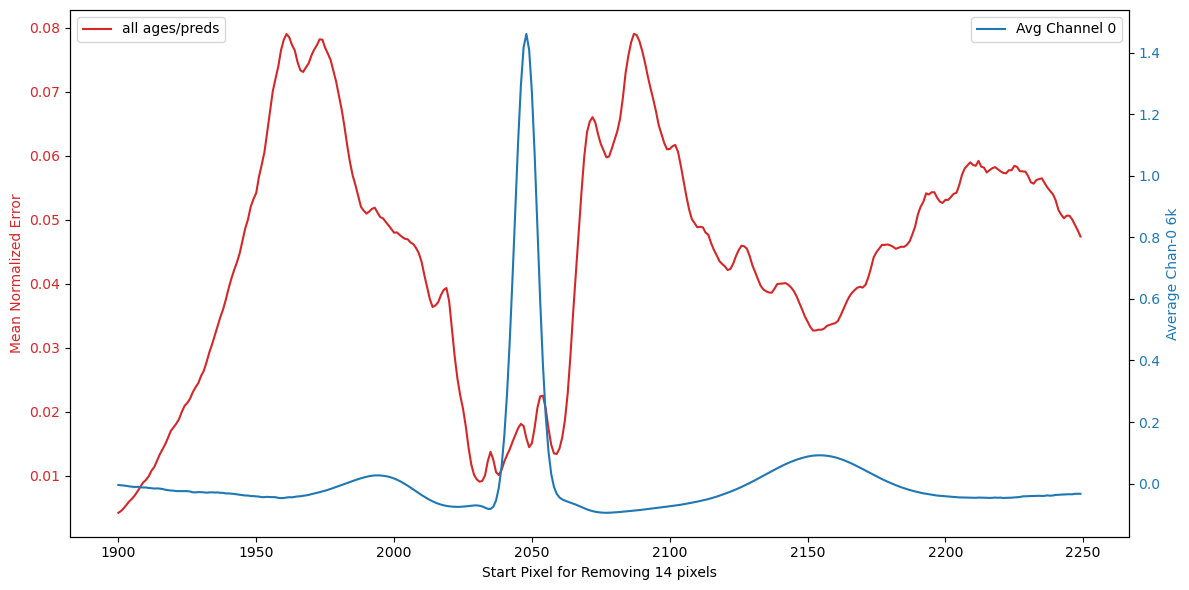

In [33]:
fig, ax1 = plt.subplots(figsize=(12, 6))
n_bins = MAX_PIX - MIN_PIX

color = 'tab:red'
ax1.set_xlabel(f'Start Pixel for Removing {pixels_removed} pixels')
ax1.set_ylabel('Mean Normalized Error', color=color)
ax1.plot(
    avg_norm_error['start_pixel'],
    avg_norm_error['norm_error'],
    color=color,
    label="all ages/preds"
)
ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Average Chan-0 6k', color=color)  # we already handled the x-label with ax1
pixels = [pix for pix in range(MIN_PIX, MAX_PIX)]
ax2.plot(pixels, chan0_avg[MIN_PIX: MAX_PIX], color=color, label='Avg Channel 0')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()



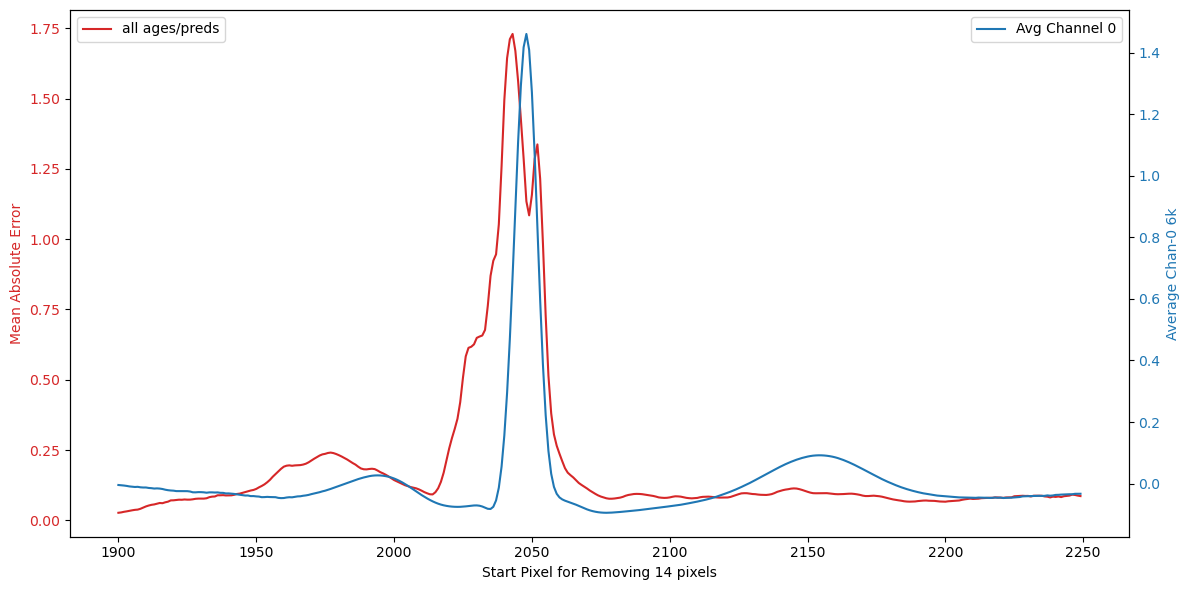

In [34]:
avg_abs_error = df.groupby(
    'start_pixel')['abs_error'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
n_bins = MAX_PIX - MIN_PIX

color = 'tab:red'
ax1.set_xlabel(f'Start Pixel for Removing {pixels_removed} pixels')
ax1.set_ylabel('Mean Absolute Error', color=color)
ax1.plot(
    avg_abs_error['start_pixel'],
    avg_abs_error['abs_error'],
    color=color,
    label="all ages/preds"
)
ax1.legend(loc='upper left')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('Average Chan-0 6k', color=color)  # we already handled the x-label with ax1
pixels = [pix for pix in range(MIN_PIX, MAX_PIX)]
ax2.plot(pixels, chan0_avg[MIN_PIX: MAX_PIX], color=color, label='Avg Channel 0')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

